# Signature Formation and Distance

## Motivation

Every Lipschitz estimate in this project's Experiment 2 (`mnist_example`) reduces to the
same ratio, `|margin_i - margin_j| / distance(x_i, x_j)` -- and every denominator tried so
far there has been a distance over the *raw pixel grid*. This notebook builds a distance from
**path signatures** of low-dimensional streams extracted from the image instead, for three
different ways of turning an image into a stream, and checks each one against plain
pixel-Euclidean distance before any of them get used for anything else.

**Sections below**: Method A (patch singular-value stream), Method B (reference-line
streams) plus its distance-function sanity check, Method C (a single Hilbert space-filling
curve) plus its cheap same/different-digit AUC screen, and finally Method B's own
hyperparameter geometry screen (which reference-line configuration produces the most
informative distance, before any adversarial evaluation is run against it).

**Adversarial/Lipschitz-ratio evaluation for all three methods, the hyperparameter sweep's
full validation stage, and every cross-method/cross-distance comparison live in the sibling
notebook, `adversarial_eval.ipynb`, not here** -- this notebook only covers how each
method's distance is built and whether it looks sane on its own terms.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import json

import matplotlib.pyplot as plt
from IPython.display import display

from signature_distance import method_b_sweep as sweep
from signature_distance import plots, run_experiment

## Section 1: Method A -- patch singular-value stream

- **Method A — patch singular-value stream**: visit a fixed, shared set of 64 interior pixel
  locations; at each, take the largest singular value of the surrounding 3x3 patch. Stream:
  `(64, 2)`, columns `[t, sigma1]`.
- **Signature**: the stream's truncated signature (depth 4), computed via `signatures.py` — the
  function shared with Method B, so results between the two methods are directly comparable.
  Full design/rationale: `README.md`.

The pixel locations are fixed and shared across every image (no dependence on a trained
classifier's own features), so the resulting streams — and their signatures — are directly
comparable across images.

## Build Method A streams and signatures for one sample image per digit

`method_a_demo` (in `run_experiment.py`) loads the fixed 1000-image eval pool
(`data_pool.load_eval_pool`), builds the 64 pixel locations once (shared across every image),
and for one sample image per digit: constructs the stream, computes its signature, and saves
an overlay + stream + signature plot to `results/`.

pool: torch.Size([1000, 28, 28]) torch.Size([1000])
pixel_order: torch.Size([64, 2])


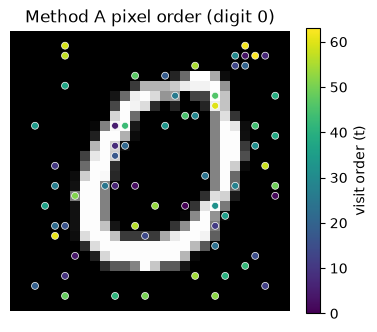

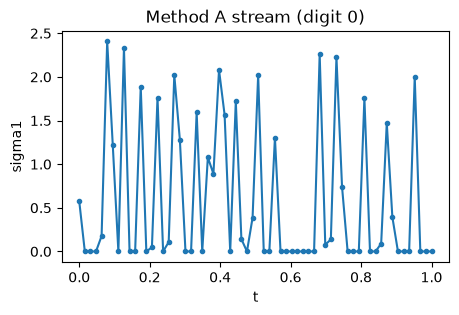

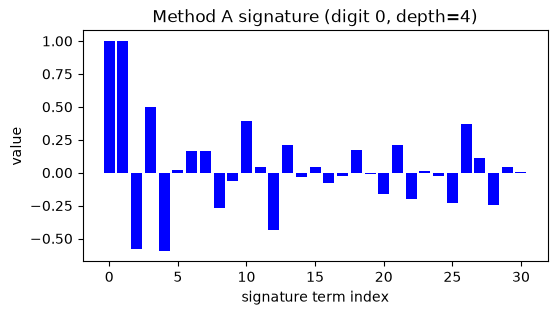

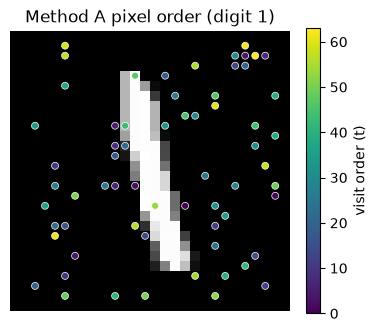

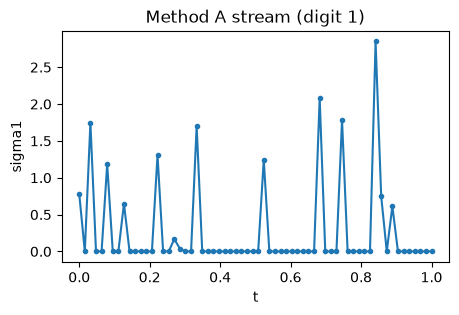

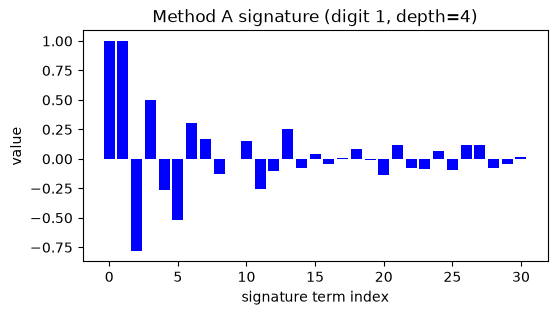

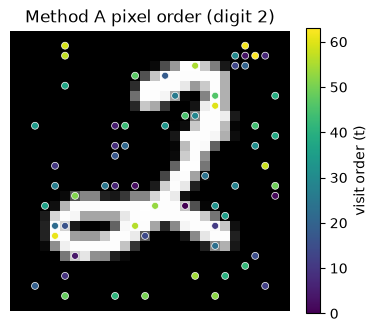

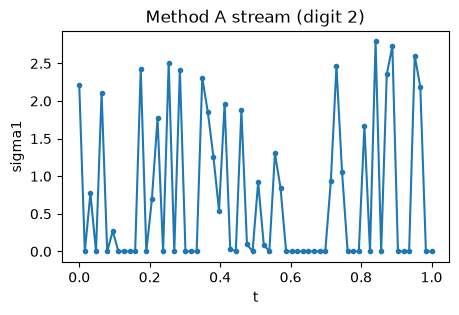

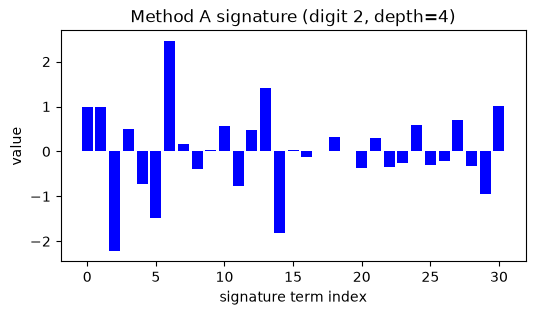

In [2]:
result = run_experiment.method_a_demo(n_digits=3)
print('pool:', result['images'].shape, result['labels'].shape)
print('pixel_order:', result['pixel_order'].shape)

## Pixel-order overlay, stream, and signature, per digit

Each digit shows three panels:
1. The 64 sampled interior patch-locations overlaid on the image, colored by visit order `t`.
2. The resulting `sigma1` vs. `t` stream — should visibly respond to whichever part of the
   digit's stroke each patch lands on.
3. The stream's truncated signature (depth 4, 31 coefficients). Index 0 is always the constant
   term (1.0); indices 1-2 are the net displacement of the `[t, sigma1]` path (`t` always ends
   at 1, so index 1 is always 1.0 too — see `signatures.py`'s closed-form tests); the rest
   capture higher-order shape of the path.

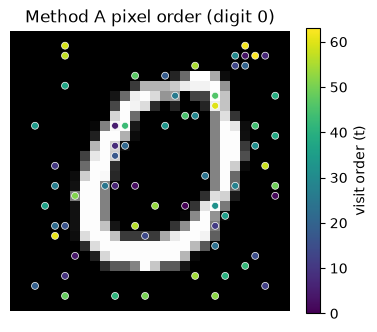

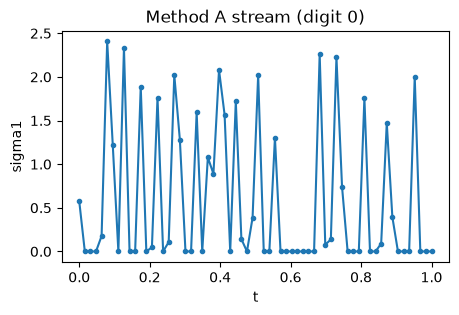

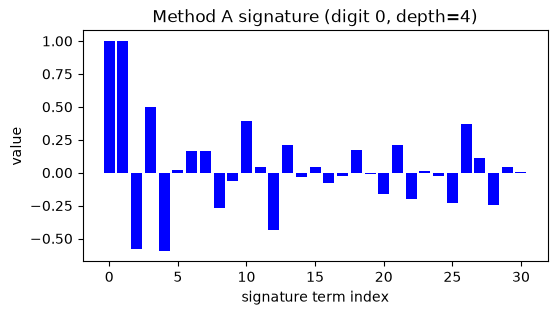

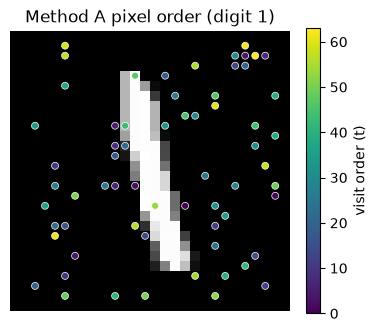

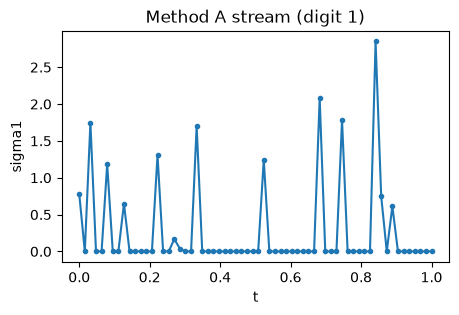

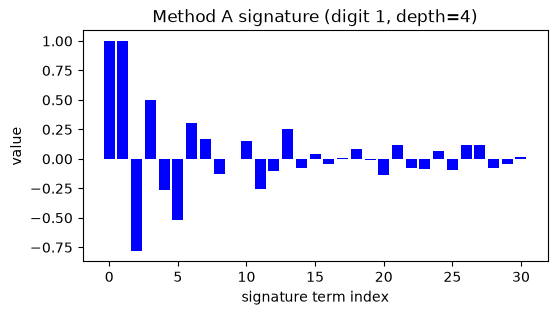

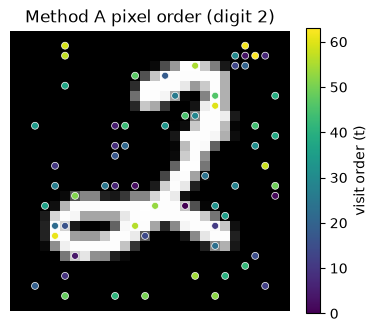

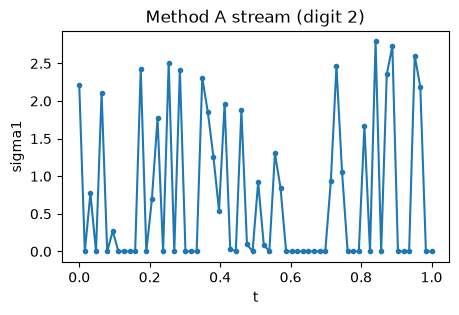

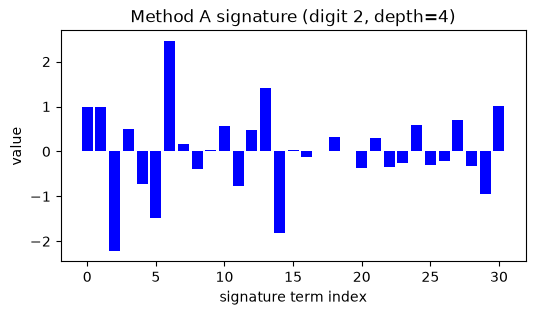

In [3]:
for digit in range(3):
    display(result['figures'][f'digit{digit}_overlay'])
    display(result['figures'][f'digit{digit}_stream'])
    display(result['figures'][f'digit{digit}_signature'])

## Status

Method A produces visually sane streams and signatures for every digit shown above — patch
locations stay interior, `sigma1` tracks the stroke, and every signature's constant term is
1.0 and finite. `signature_of_stream` (shared with Method B) is verified against closed-form
identities in `tests/test_signatures.py` / `tests/test_signatures_method_b.py` — a straight-line
path's signature matches the exact tensor exponential, and an L-shaped path matches a
hand-computed area term — before being trusted here.

Phase 3 (distance function over the signature) and Phase 4 (within/cross-digit sanity check)
have since landed (`distances.py`, `run_experiment.sanity_check_demo`) — Method A's numbers are
`r ≈ 1.656`, within-digit mean 14.60, cross-digit mean 17.18, ratio 1.176 (documented in
`README.md`'s Results section; this notebook hasn't been re-executed to show that cell directly).
The section below runs a further diagnostic on top of that same Phase 3/4 pipeline.

## Level-wise decomposition of the signature distance

Method A's stream is `(t, sigma1)`, and the time channel is identical for every image
(`arange(64)/63`), so it contributes exactly zero to any pairwise distance. That means the
entire level-1 content of the signature reduces to a single scalar:
`Δσ1 = sigma1(anchor 63) − sigma1(anchor 0)` — the difference of two 3x3 patch singular values
out of 64 anchors. If the Phase 4 ratio (1.176) turned out to be carried entirely by that one
scalar, the signature machinery at levels 2-4 would be doing no work.

`level_decomposition.py` checks this directly (read-only diagnostic, doesn't change the
distance/stream/signature pipeline above): masks the rescaled signature down to specific levels
before computing the same within/cross-digit sanity check, on the same 300-image sample
(30/class, seed 0) `run_experiment.sanity_check_demo` uses. Full detail (both methods, per-level
squared-distance contribution table): `README.md`.

In [4]:
import json

from signature_distance.distances import run_level_decomposition

decomposition = run_level_decomposition(n_per_class=30, seed=0, depth=4)

print('r_a:', decomposition['r_a'])
print()
print('variants (method_a):')
print(json.dumps(
    {label: entry['method_a'] for label, entry in decomposition['variants'].items()},
    indent=2,
))
print()
print('per-level fraction of total squared distance (method_a):')
print(json.dumps(decomposition['level_fraction']['method_a'], indent=2))

r_a: 1.6562802961332312

variants (method_a):
{
  "all": {
    "within_digit_mean": 14.601261138916016,
    "cross_digit_mean": 17.17684555053711,
    "ratio_cross_over_within": 1.176394654346433
  },
  "level1_only": {
    "within_digit_mean": 1.4976660013198853,
    "cross_digit_mean": 1.9109095335006714,
    "ratio_cross_over_within": 1.2759250272200857
  },
  "level2plus": {
    "within_digit_mean": 14.503375053405762,
    "cross_digit_mean": 17.045391082763672,
    "ratio_cross_over_within": 1.1752706538993474
  },
  "level2_only": {
    "within_digit_mean": 4.544910430908203,
    "cross_digit_mean": 5.580887794494629,
    "ratio_cross_over_within": 1.2279423058683707
  },
  "level3_only": {
    "within_digit_mean": 7.899548530578613,
    "cross_digit_mean": 9.377066612243652,
    "ratio_cross_over_within": 1.1870382941437307
  },
  "level4_only": {
    "within_digit_mean": 11.178051948547363,
    "cross_digit_mean": 12.983956336975098,
    "ratio_cross_over_within": 1.16155806009

**Finding: the higher-order levels carry the signal, not the level-1 scalar.** `level2plus`
(levels 2-4, level 1 dropped entirely) reproduces the full `all` ratio almost exactly
(1.175 vs. 1.176) — dropping the single `Δσ1` scalar costs almost nothing. The per-level
fraction table sharpens this further: level 1 carries only ~1.8% of the total squared
pairwise distance, versus ~58% for level 4 alone. So Method A's Phase 4 ratio is not a
relabelled version of `Δσ1` — that scalar is a minor contributor, and the signature machinery
above it is doing real work.

One wrinkle worth keeping in mind rather than smoothing over: level 1 alone actually posts the
*highest* individual-level ratio (1.276, above `all`'s 1.176) despite its tiny magnitude share —
a level can be a relatively good per-unit class-separator while barely moving the distance in
absolute terms. Ratio and magnitude are answering different questions, and neither alone is
the full picture (see `README.md` for the same pattern, inverted, at
level 4). Per this project's convention, this is carried forward as an honest finding, not
argued away — it doesn't change Phase 4's already-documented modest effect size relative to the
pixel-space Euclidean baseline.

## Pixel-order robustness check

README.md flags Method A's pixel visiting order (`make_pixel_order`, a seeded
`torch.randperm`) as "a random sample, not a spatially coherent walk" — worth checking whether
the level-decomposition finding above depends on which particular 64-pixel sample/order was
used, or holds regardless.

`run_level_decomposition` takes an optional `pixel_order_seed`, independent of `seed` (which
controls the eval pool) — it defaults to reusing `seed`, so the cell above was implicitly
`pixel_order_seed=0`. Below: the same 300-image pool (seed 0) held fixed throughout, run for 4
more pixel orders (`pixel_order_seed` 1-4) and compared against the seed-0 baseline above.
Method B is unaffected either way — `make_reference_lines`'s line geometry doesn't depend on a
seed.

In [5]:
import pandas as pd

pixel_order_seeds = [0, 1, 2, 3, 4]
po_results = {
    s: run_level_decomposition(n_per_class=30, seed=0, depth=4, pixel_order_seed=s)
    for s in pixel_order_seeds
}

print('r_a per pixel_order_seed:')
display(pd.Series({s: r['r_a'] for s, r in po_results.items()}, name='r_a').to_frame())

ratio_table = pd.DataFrame({
    s: {v: entry['method_a']['ratio_cross_over_within'] for v, entry in r['variants'].items()}
    for s, r in po_results.items()
})
print('ratio (cross/within) per variant, per pixel_order_seed:')
display(ratio_table.round(4))

fraction_table = pd.DataFrame({
    s: r['level_fraction']['method_a'] for s, r in po_results.items()
})
print('per-level squared-distance fraction (%), per pixel_order_seed:')
display((fraction_table * 100).round(2))

r_a per pixel_order_seed:


,r_a
0,1.656280
1,1.500071
2,1.500396
3,1.583648
4,1.571740


ratio (cross/within) per variant, per pixel_order_seed:


,0,1,2,3,4
all,1.1764,1.2549,1.1890,1.2186,1.2780
level1_only,1.2759,1.4191,1.2738,1.2680,1.3667
level2plus,1.1753,1.2527,1.1873,1.2184,1.2776
level2_only,1.2279,1.3668,1.1958,1.2552,1.3521
level3_only,1.1870,1.2660,1.2140,1.2288,1.3115
level4_only,1.1616,1.2277,1.1751,1.2095,1.2534


per-level squared-distance fraction (%), per pixel_order_seed:


,0,1,2,3,4
1,1.79,3.06,4.04,1.77,2.33
2,11.35,13.12,11.46,11.54,12.32
3,28.85,24.73,27.80,28.82,27.02
4,58.01,59.09,56.70,57.87,58.33


**Finding: the two conclusions above are robust across pixel orders — only the effect size moves.**

The `all`-variant ratio ranges 1.176–1.278 across the 5 orders (mean ≈1.223, std ≈0.038, ~8%
peak-to-peak) — a real, moderate sensitivity to exactly which 64 interior pixels get sampled and
in what order, consistent with the "random sample, not a spatially coherent walk" caveat this
check was meant to test. `r_a` moves similarly (1.500–1.656).

But the two qualitative findings from the level decomposition above hold in *every* one of the 5
pixel orders, not just the original:

1. **`level2plus ≈ all`, always.** The gap between them is ≤0.004 in every row — dropping level 1
   entirely never costs anything meaningful, regardless of which pixels/order were used. Verdict
   (b) (higher-order levels carry the signal) isn't an artifact of one particular sample.
2. **Level 1 is always the "high ratio, low magnitude" outlier.** `level1_only` has the *highest*
   per-level ratio in all 5 orders (up to 1.419 at `pixel_order_seed=1`), while carrying the
   least magnitude every time (1.8–4.0%, always under 5%). `level4_only` is the mirror image:
   lowest ratio, most magnitude (57–59%), in all 5 orders. Magnitude fraction increases
   monotonically level 1→4 in every run; the ratio ordering is not perfectly monotonic (level 3
   edges out level 2 at `pixel_order_seed=2`), but level 1 highest / level 4 lowest never breaks.

Per this project's convention, this is carried forward as the honest picture: the *direction* and
*shape* of the level-decomposition finding is stable, but the specific numbers (and Method A's
headline Phase 4 ratio itself) depend non-trivially on the particular random pixel sample —
worth keeping in mind before treating any single run's ratio as a precise, reproducible constant.

## Section 2: Method B -- reference-line streams

Method B represents each MNIST image as 16 fixed reference lines through the image
(8 horizontal + 8 vertical in the original design - see the sweep notebook for the
current best configuration), each sampled at 32 points via bilinear interpolation into
a `[t, intensity]` stream. Each line's stream gets its own truncated path signature
(`signatures.py`, verified against closed-form identities - a straight line matches the
exact tensor exponential, an L-shaped path matches a hand-computed area term). The 16
lines and their signatures are never merged at this stage -- see the distance function and
sanity check right below, and `adversarial_eval.ipynb` for what's built on top of this.

pool: torch.Size([1000, 28, 28]) torch.Size([1000])
lines: torch.Size([16, 32, 2])


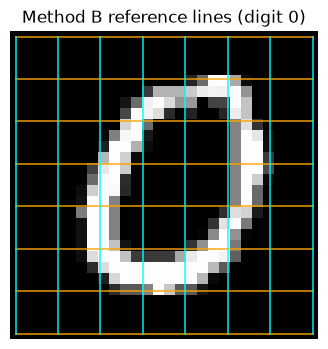

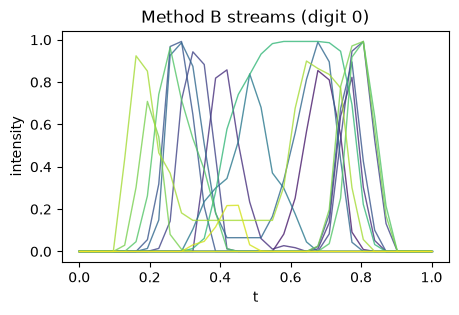

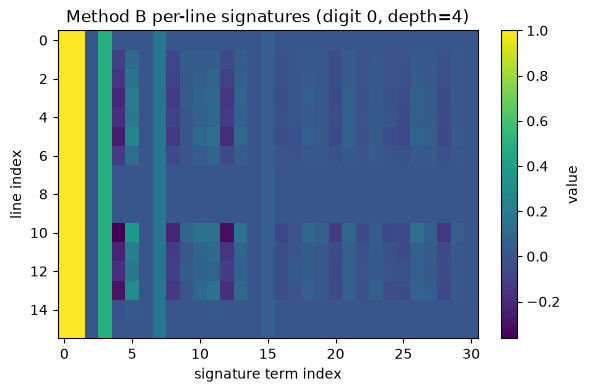

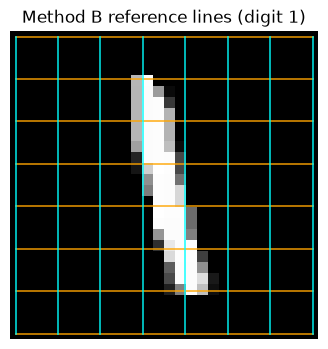

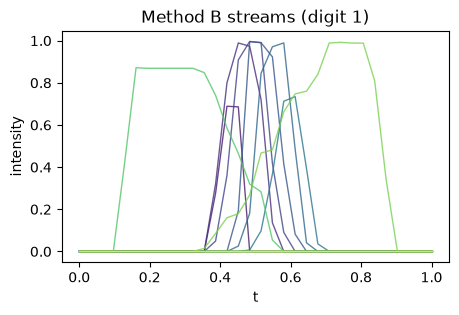

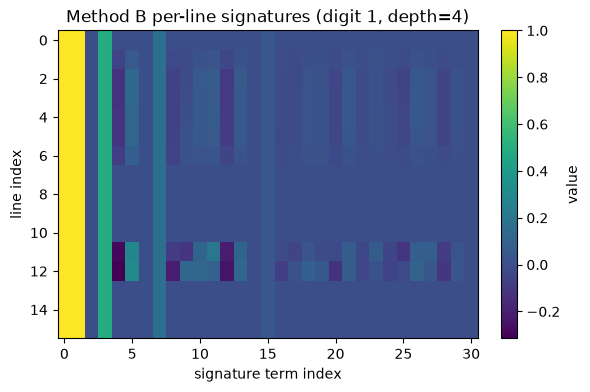

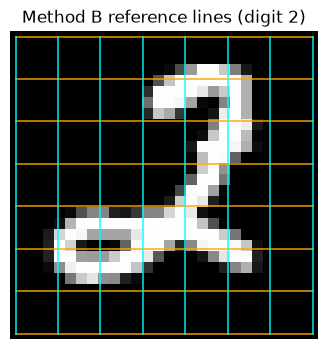

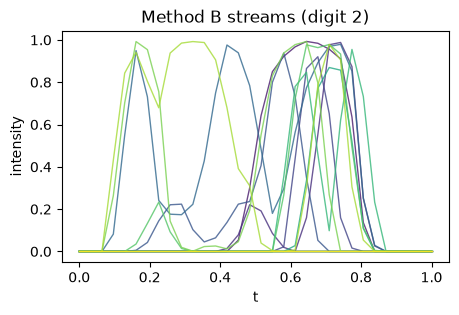

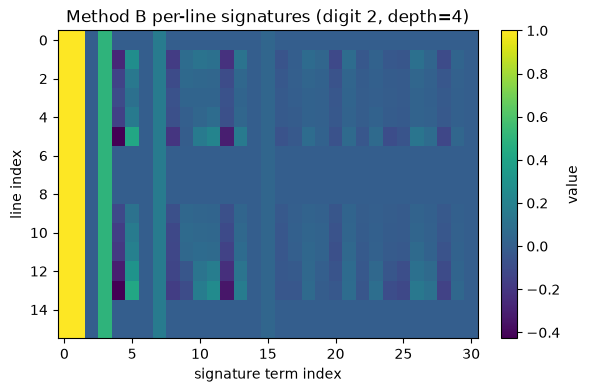

In [6]:
result = run_experiment.stream_construction_demo(n_digits=3)
print('pool:', result['images'].shape, result['labels'].shape)
print('lines:', result['lines'].shape)

Per digit: the reference lines overlaid on the image, the resulting per-line intensity
streams, and a heatmap of all 16 lines' signatures.

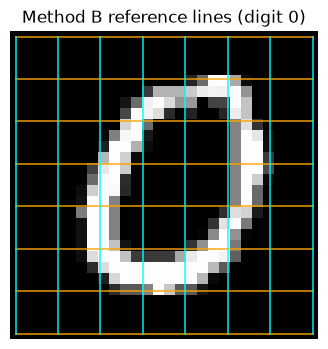

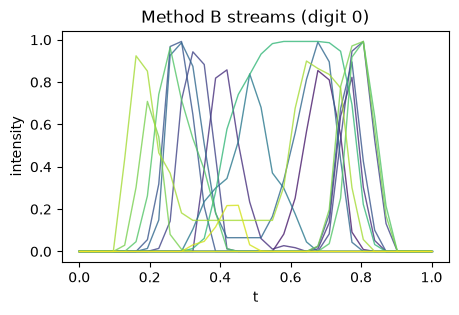

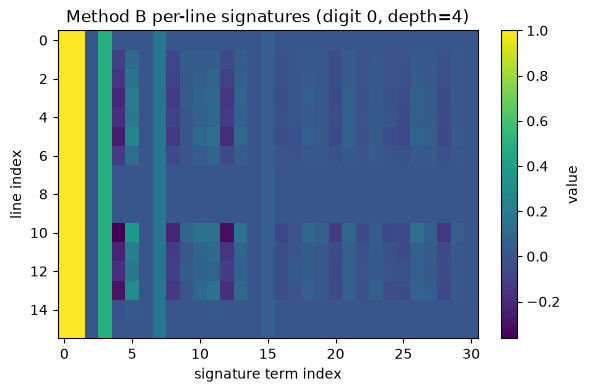

In [7]:
display(result['figures']['digit0_overlay'])
display(result['figures']['digit0_stream'])
display(result['figures']['digit0_signature'])

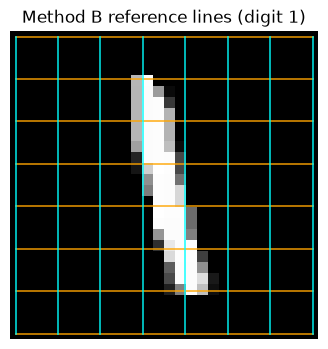

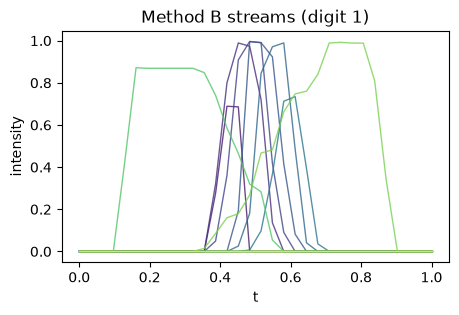

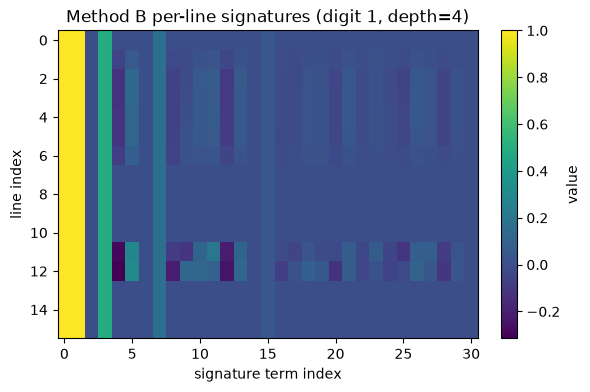

In [8]:
display(result['figures']['digit1_overlay'])
display(result['figures']['digit1_stream'])
display(result['figures']['digit1_signature'])

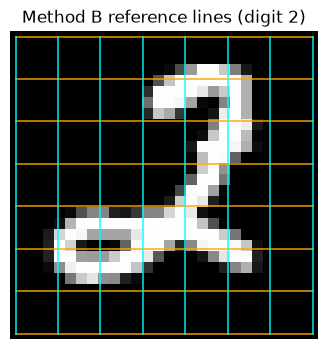

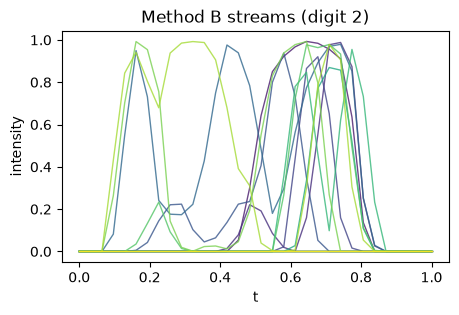

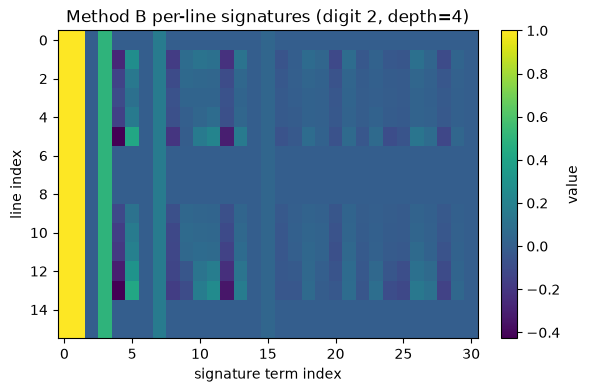

In [9]:
display(result['figures']['digit2_overlay'])
display(result['figures']['digit2_stream'])
display(result['figures']['digit2_signature'])

**Status**: streams and signatures are visually sane for every digit - reference lines
span the full image, intensity streams show clear bumps where a line crosses the digit,
and every line's signature has constant term 1.0 and is finite. This is the foundation;
`the Method B section of `adversarial_eval.ipynb`` covers the distance function, sanity checks, two
rounds of adversarial evaluation, and the hyperparameter sweep that found a better
configuration than the one shown here.

## Distance function and sanity check

Each line's signature is rescaled level-`n` by `r**n` (raw coefficients decay ~1/n! with
depth) and the 16 rescaled per-line signatures are concatenated into one 496-dim feature
vector per image. Within-digit vs. cross-digit mean distance on a 300-image sample:

In [10]:
sanity = run_experiment.sanity_check_demo(n_per_class=30, seed=0)
print(json.dumps(sanity['method_b'], indent=2))

{
  "r": 2.8597598377587485,
  "raw": {
    "within_digit_mean": 0.8844699859619141,
    "cross_digit_mean": 1.052048921585083,
    "ratio_cross_over_within": 1.1894681993543477
  },
  "rescaled": {
    "within_digit_mean": 28.598134994506836,
    "cross_digit_mean": 33.166927337646484,
    "ratio_cross_over_within": 1.1597584018684166
  }
}


Within-digit pairs were closer than cross-digit pairs (ratio ~1.16), so the distance
was behaving sensibly - but only about as well as plain raw-pixel Euclidean distance
(~1.13), not clearly better. This motivated testing it on the actual task it was built
for (adversarial/Lipschitz-ratio evaluation) rather than tuning further on this weak signal
alone.

## Section 3: Method C -- Hilbert space-filling curve

A single space-filling curve through the image, in place of Method B's 16 straight
reference lines: an order-5 Hilbert curve (1024 cells on a 32x32 grid), scaled into the
28x28 image domain and resampled to 512 points evenly spaced along its arc length, then
cut into 16 contiguous segments of 32 points each - the same total point budget as
Method B's current default (16 lines x 32 points), so the two methods can be compared
fairly. Each segment gets its own signature and its own local Lipschitz ratio, following
the same per-path (never-merged) evaluation approach used for Method B - the 16 segments
are examined as a collection, never combined into a single vector before comparison.

Everything downstream of stream construction reuses Method B's existing infrastructure
unchanged: signature computation, level-rescaling, the per-segment distance function, the
adversarial evaluation machinery, and the same/different-digit AUC diagnostic.

In [11]:
import torch
from types import SimpleNamespace

from signature_distance import distances, plots, streams

# Compatibility shim: this notebook was originally written against a separate
# hilbert_stream.py module, since folded into streams.py/distances.py/plots.py
# as part of the reorganization -- re-exported under the original short alias
# so the call sites below (hc.foo()) resolve unchanged.
hc = SimpleNamespace(
    NUM_SEGMENTS=streams.NUM_SEGMENTS,
    hilbert_stream=streams.hilbert_stream,
    make_hilbert_curve=streams.make_hilbert_curve,
    plot_hilbert_curve=plots.plot_hilbert_curve,
    plot_hilbert_segment_streams=plots.plot_hilbert_segment_streams,
    plot_hilbert_signatures=plots.plot_hilbert_signatures,
    plot_depth_comparison=plots.plot_depth_comparison,
    evaluate_hilbert_depths=distances.evaluate_hilbert_depths,
)

## Construction

The curve generator was checked directly before anything was built on it: every one of
the 1024 cells is visited exactly once, every coordinate stays in bounds, and every
consecutive pair of cells is exactly one grid unit apart, always axis-aligned. The 512
sample points are then placed evenly along the curve's actual arc length (not simple
index subsampling of the 1024 raw points - those are not the same thing once a path
bends, which the Hilbert curve constantly does).

In [12]:
curve = hc.make_hilbert_curve()
print('curve shape:', curve.shape)
print('row/col range:', curve.min().item(), '-', curve.max().item())

curve shape: torch.Size([512, 2])
row/col range: 0.0 - 27.125


## Curve, stream, and signature per digit

Each digit shows three panels: the curve overlaid on the image (color = position along
the curve, red dots = the 16 segment boundaries), the resulting per-segment intensity
streams, and a heatmap of all 16 segments' signatures.

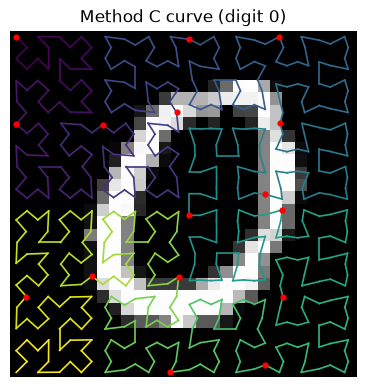

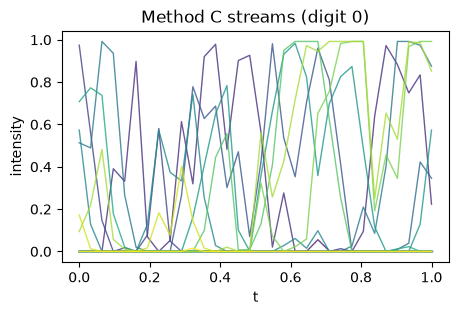

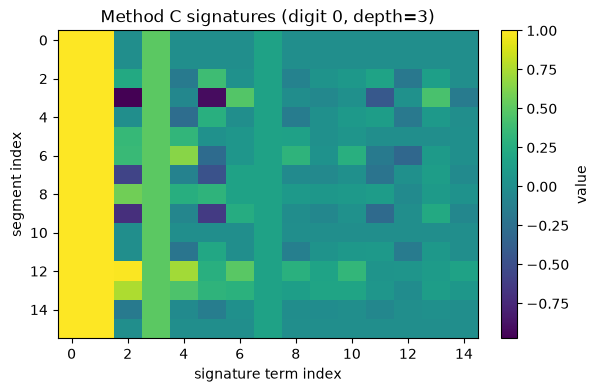

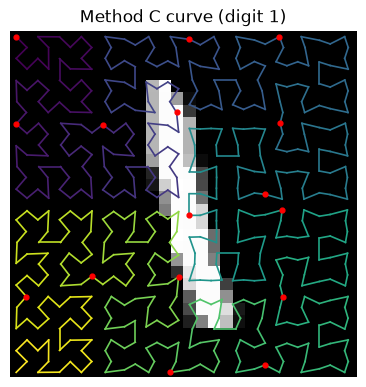

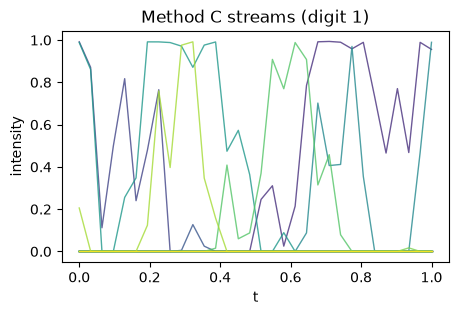

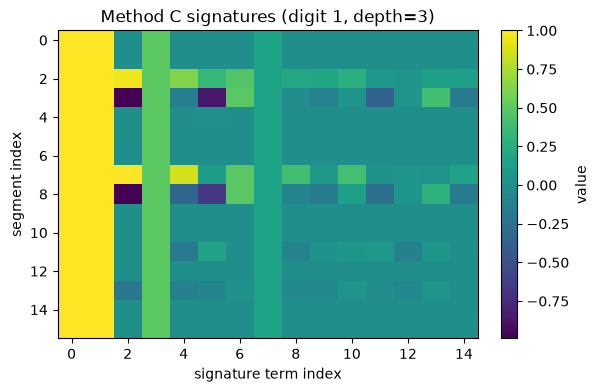

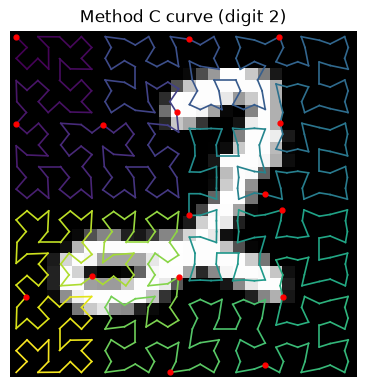

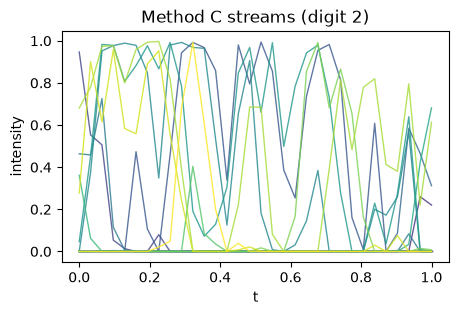

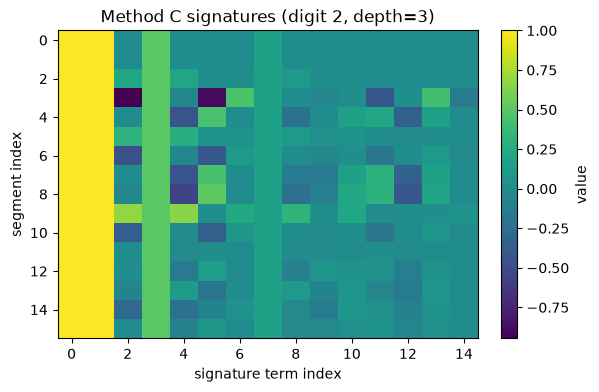

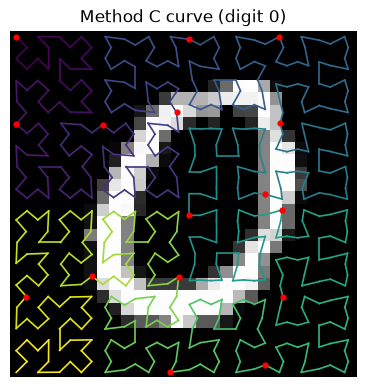

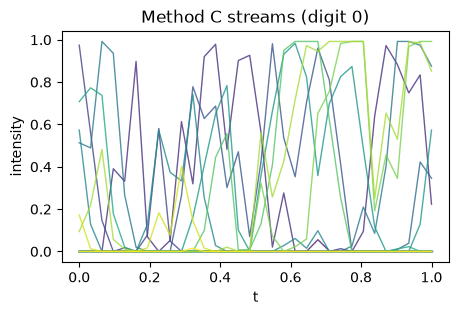

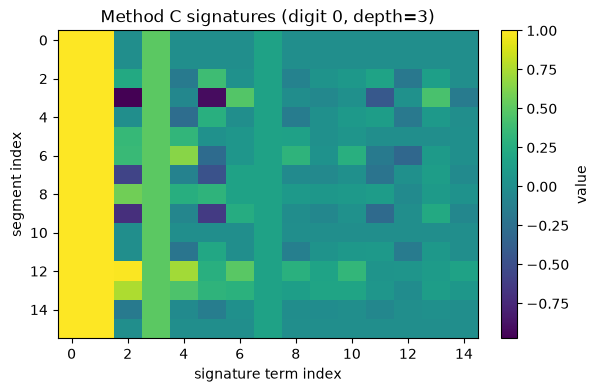

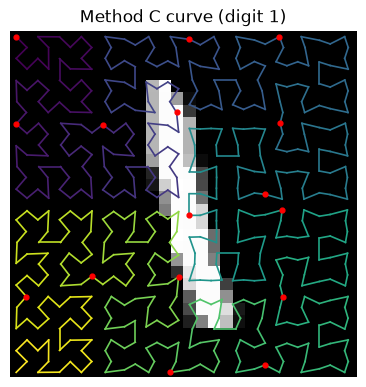

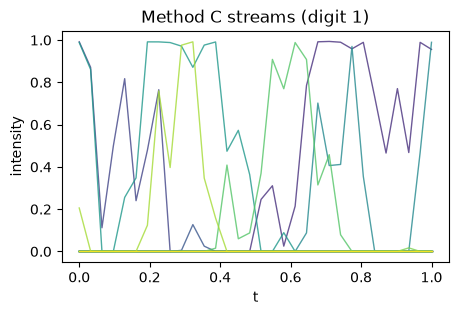

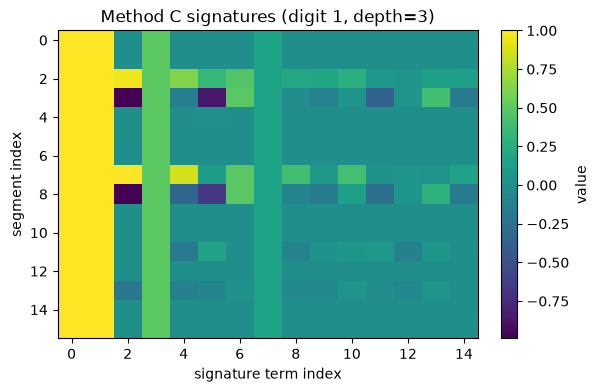

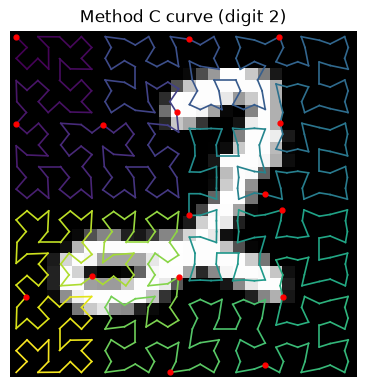

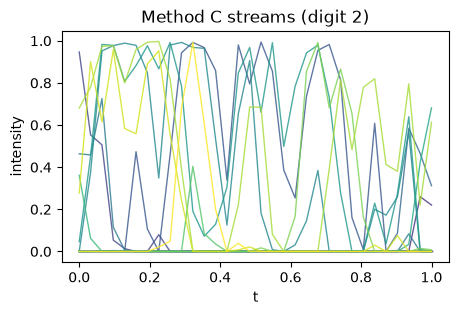

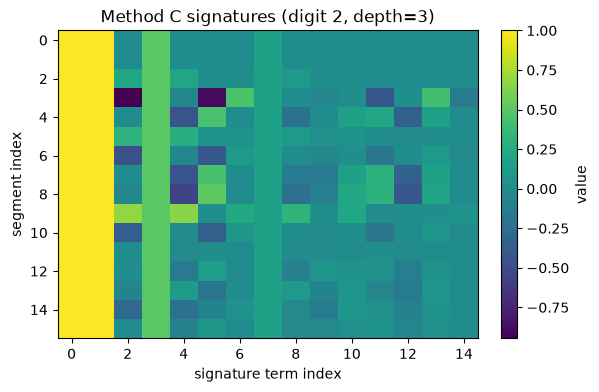

In [13]:
from signature_distance.data_pool import load_eval_pool
from signature_distance.signatures import signature_of_stream

images, labels = load_eval_pool(n_per_class=100, seed=0)

for digit in range(3):
    idx = (labels == digit).nonzero()[0].item()
    image = images[idx]
    stream = hc.hilbert_stream(image.unsqueeze(0), curve)[0]
    sig = signature_of_stream(stream, depth=3)

    display(hc.plot_hilbert_curve(image, curve, title=f"Method C curve (digit {digit})"))
    display(hc.plot_hilbert_segment_streams(stream, title=f"Method C streams (digit {digit})"))
    display(hc.plot_hilbert_signatures(sig, title=f"Method C signatures (digit {digit}, depth=3)"))

## Stage A: depth mini-sweep

Method B's sweep found depth 2 clearly and monotonically best for straight reference
lines - there was no reason to assume that transfers to a contiguous, space-filling
traversal with different local statistics, so depth was swept separately here.

depth=2: r=2.682  best_auc=0.6485  mean_auc=0.5654  n_informative=16/16
depth=3: r=3.003  best_auc=0.6537  mean_auc=0.5655  n_informative=16/16
depth=4: r=3.178  best_auc=0.6475  mean_auc=0.5633  n_informative=16/16


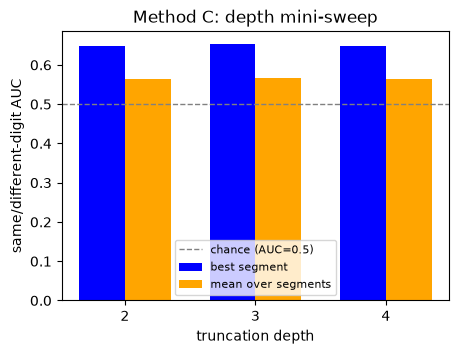

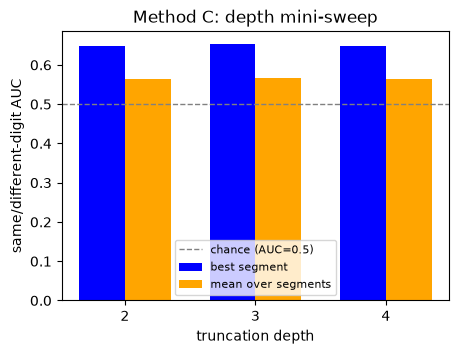

In [14]:
depth_results = hc.evaluate_hilbert_depths(n_per_class=30, seed=0, depths=(2, 3, 4))

for depth, e in depth_results.items():
    print(f"depth={depth}: r={e['r']:.3f}  best_auc={e['best_auc']:.4f}  mean_auc={e['mean_auc']:.4f}  "
          f"n_informative={e['n_informative']}/{e['n_segments']}")

display(hc.plot_depth_comparison(depth_results))

Depth 3 wins, but narrowly - about 0.008 higher best-segment AUC than depth 2, and
essentially tied on mean AUC. This is a genuinely different pattern from Method B's
sweep, where depth 2 beat depth 6 by roughly 0.026 AUC in a clean, monotonic trend; here
the three depths tested sit close together with no strong trend either way. Depth 3 was
carried forward for the full validation below, though the margin over depth 2 is small
enough that it should not be read as a strongly established optimum the way Method B's
depth-2 result was.

Every one of the 16 segments carried above-chance signal at every depth tested - unlike
Method B, where 4 of 16 lines sat at exact chance level (the ones running along the
image border). A space-filling curve has no equivalent to a straight line placed exactly
on the border; every segment covers a genuinely different, non-degenerate arc of the
image regardless of where it falls in the traversal order.

## Section 4: Method B -- hyperparameter geometry screen (Stage A)

## Hyperparameter sweep: geometry, points/line, depth, interpolation

Stage A: a cheap screen (no model training) scoring the joint grid - line geometry
(orientation split), points per line, truncation depth, and interpolation (linear vs.
cubic spline) - by the same per-path same/different-digit AUC used above. A depth-D
signature's lower-level coefficients are an exact prefix of a higher-depth computation
(verified directly), so each (geometry, points, interpolation) stream only needs the
expensive signature step run once, at the maximum depth swept.

In [15]:
stage_a_rows = sweep.run_stage_a_sweep(n_per_class=15, seed=0, verbose=True)

print(f"{'geometry':>18} {'pts':>4} {'depth':>5} {'interp':>7} {'best_auc':>9}")
for row in stage_a_rows[:8]:
    print(f"{row['geometry']:>18} {row['points_per_line']:>4} {row['depth']:>5} "
          f"{row['interpolation']:>7} {row['best_auc']:>9.4f}")

  [1/32] 8h+8v (baseline), points=16, interp=linear done


  [2/32] 8h+8v (baseline), points=16, interp=cubic done


  [3/32] 8h+8v (baseline), points=32, interp=linear done


  [4/32] 8h+8v (baseline), points=32, interp=cubic done


  [5/32] 8h+8v (baseline), points=48, interp=linear done


...

  [28/32] 0h+16v, points=32, interp=cubic done


  [29/32] 0h+16v, points=48, interp=linear done


  [30/32] 0h+16v, points=48, interp=cubic done


  [31/32] 0h+16v, points=64, interp=linear done


  [32/32] 0h+16v, points=64, interp=cubic done
          geometry  pts depth  interp  best_auc
            12h+4v   16     2  linear    0.6811
            12h+4v   16     2   cubic    0.6810
            12h+4v   32     2  linear    0.6807
            12h+4v   32     2   cubic    0.6806
            12h+4v   64     2   cubic    0.6804
            12h+4v   64     2  linear    0.6804
            12h+4v   48     2  linear    0.6802
            12h+4v   48     2   cubic    0.6801


In [16]:
from collections import defaultdict

for axis in ('depth', 'geometry', 'points_per_line', 'interpolation'):
    by_axis = defaultdict(list)
    for row in stage_a_rows:
        by_axis[row[axis]].append(row['best_auc'])
    print(f"=== best_auc by {axis} ===")
    for k, vals in by_axis.items():
        print(f"  {k}: mean={sum(vals)/len(vals):.4f}")
    print()

=== best_auc by depth ===
  2: mean=0.6585
  3: mean=0.6512
  4: mean=0.6435
  5: mean=0.6372
  6: mean=0.6320

=== best_auc by geometry ===
  12h+4v: mean=0.6592
  8h+8v (baseline): mean=0.6492
  16h+0v: mean=0.6477
  0h+16v: mean=0.6219

=== best_auc by points_per_line ===
  16: mean=0.6388
  32: mean=0.6461
  64: mean=0.6468
  48: mean=0.6463

=== best_auc by interpolation ===
  linear: mean=0.6437
  cubic: mean=0.6453



Depth was the dominant lever - a monotonic improvement from depth 6 down to depth 2,
meaning the original default (depth 4) was not the best choice. Geometry mattered too
(shifting weight toward horizontal lines helped; all-vertical was clearly worst).
Points-per-line and interpolation barely mattered, plateauing quickly. Best single
config on this cheap, no-model-training AUC screen: 12 horizontal + 4 vertical lines,
depth 2 - a real, robust improvement over the baseline, not a single lucky row (the
whole top cluster agreed).

Stage B validates the top finalists with the full per-path adversarial evaluation
(canonical SmallCNN/StrongCNN checkpoint, loaded once, reused across every finalist) --
see `adversarial_eval.ipynb`'s Method B section for that validation. **Stage A and
Stage B now pick different winners** (Stage A: 12h+4v; Stage B: 16h+0v, on the properly-
trained models) - not a bug in either, since they measure different things (clean-image
same/different-digit separation here vs. adversarial-vs-random-noise separation there);
see that notebook's Stage 8 verdict for the full explanation.

## Section 5: distance-measure effectiveness -- all three methods vs. pixel-Euclidean

Each method's own section above checked its within-vs-cross-digit ratio in isolation. This
section puts all three side by side against the plain pixel-Euclidean baseline, on the same
300-image sample (30/class, seed 0) throughout -- Method A's figure reuses the
`decomposition` result already computed above (its `all`-variant ratio); Method B and Method
C, plus the pixel-Euclidean baseline, come from `distances.run_cross_within_comparison`,
which computes all three under one consistent convention in a single call.

pixel-Euclidean:        ratio=1.1454
Method B merged (winner config): ratio=1.3249
  (degenerate/border lines excluded from per-line stats: [0, 15])
Method B per-line mean:  ratio=1.4672  (best=2.1516, worst=1.1904)
Method C merged:         ratio=1.1684
Method C per-segment mean: ratio=1.1914  (best=1.3635, worst=1.0765)
{
  "Pixel-Euclidean": 1.1453963263199622,
  "Method A": 1.176394654346433,
  "Method B (merged, winner config)": 1.3248950598260831,
  "Method C (merged)": 1.1684374026154163
}


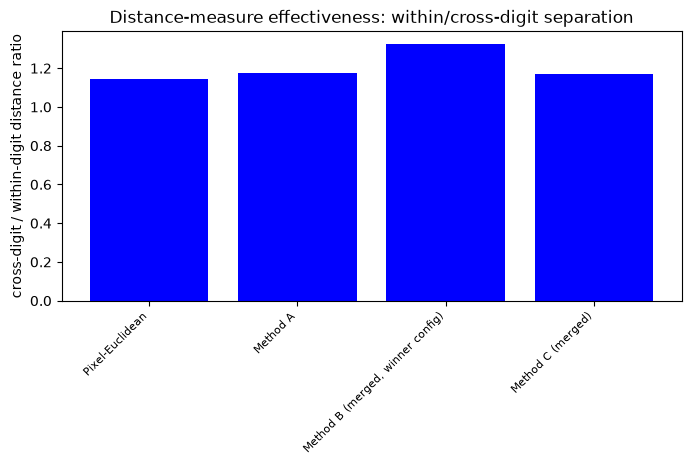

In [17]:
from signature_distance.distances import run_cross_within_comparison

comparison = run_cross_within_comparison(n_per_class=30, seed=0, verbose=True)

distance_ratios = {
    "Pixel-Euclidean": comparison["pixel"]["ratio_cross_over_within"],
    "Method A": decomposition["variants"]["all"]["method_a"]["ratio_cross_over_within"],
    "Method B (merged, winner config)": comparison["method_b"]["merged"]["ratio_cross_over_within"],
    "Method C (merged)": comparison["method_c"]["merged"]["ratio_cross_over_within"],
}
print(json.dumps(distance_ratios, indent=2))

fig = plots.plot_per_line_bar(
    distance_ratios,
    title="Distance-measure effectiveness: within/cross-digit separation",
    ylabel="cross-digit / within-digit distance ratio",
)
display(fig)
plt.close(fig)

**Method B's optimized (winner-config) geometry is the one signature distance that shows a
real improvement over plain pixel-Euclidean here** -- 1.32x vs. 1.15x, roughly 16%
higher separation. Method A (1.18x) and Method C (1.17x) sit much closer to the Euclidean
baseline, not clearly better on this particular check. Note the comparability caveat: Method
B's number here uses its post-sweep winning geometry (16h+0v, depth 2), found in Section 4
specifically to maximize this kind of same/different-digit signal -- Method A and Method C are
shown at their original, non-swept defaults, so this isn't a perfectly apples-to-apples
comparison of the three methods' ceilings, only of what's actually been built and validated so
far. This within/cross-digit check is a weaker signal than this project's actual evaluation
target (adversarial/Lipschitz-ratio separation) either way -- see `adversarial_eval.ipynb`'s own
distance-measure comparison for that picture, which is substantially stronger for Method B.